In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")

EXCEL_PATH = "Manual_evaluation.xlsx"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

EXPERIMENTS = {
    "ZeroShot-V1":          {"sheet": "zeroshot_v1",          "header": 0},
    "FewShot-5-Random-V1":  {"sheet": "fewshot_5_random_v1",  "header": 0},
    "FewShot-5-Random-V2":  {"sheet": "fewshot_5_random_v2",  "header": 0},
    "FewShot-10-Random-V1": {"sheet": "fewshot_10_random_v1", "header": 0},
    "FewShot-10-Random-V2": {"sheet": "fewshot_10_random_v2", "header": 0},
    "Manual-Prompting":     {"sheet": "manual_exp",           "header": 0},
}

MODEL_COLS = ["ChatGPT", "Gemini", "DeepSeek"]
SHEET_MODEL_MAP = {"ChatGPT": "ChatGPT", "Gemini": "Gemini", "DeepSeek": "Deepseek"}

# SIDs to exclude per sheet (e.g., SID 15 was an example in 10-shot experiments)
EXCLUDE_SIDS = {
    "fewshot_10_random_v1": [15],
    "fewshot_10_random_v1_old": [15],
}

In [2]:
def analyze_experiment(sheet_name, title, header=0, save=True):
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, header=header)
    df.columns = [str(c) for c in df.columns]

    # Exclude known example SIDs (stories that were used as examples, not targets)
    if sheet_name in EXCLUDE_SIDS:
        sid_col = [c for c in df.columns if "SID" in str(c).upper() or "sid" in str(c)]
        if sid_col:
            before = len(df)
            df = df[~df[sid_col[0]].isin(EXCLUDE_SIDS[sheet_name])]
            if len(df) < before:
                print(f"  (excluded {before - len(df)} row(s) for SID(s) {EXCLUDE_SIDS[sheet_name]})")

    # Identify score columns for each model
    score_cols = {}
    for mdl, sheet_mdl in SHEET_MODEL_MAP.items():
        candidates = [c for c in df.columns if sheet_mdl in str(c) and "Unnamed" not in str(c)]
        # Score col is the first non-SID, non-Evaluated, non-Remarks column for this model
        for c in candidates:
            if "emarks" not in str(c) and "ass?" not in str(c) and "valuated" not in str(c):
                score_cols[mdl] = c
                break

    stats = []
    for mdl in MODEL_COLS:
        col = score_cols.get(mdl)
        if col is None or col not in df.columns:
            continue
        scores = df[col].dropna()
        n = len(scores)
        if n == 0:
            stats.append({"Experiment": title, "Model": mdl, "N": 0,
                          "Pass Rate": None, "Pass": 0, "Fail": 0})
            continue
        passes = (scores >= 4).sum()
        fails = (scores < 4).sum()
        pass_rate = passes / n
        stats.append({"Experiment": title, "Model": mdl, "N": n,
                      "Pass Rate": round(pass_rate, 3),
                      "Pass": passes, "Fail": fails})

    result = pd.DataFrame(stats)

    # ── Print summary ──
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(result[["Model", "N", "Pass Rate", "Pass", "Fail"]].to_string(index=False))
    print()

    # ── Pass rate bar chart ──
    fig, ax = plt.subplots(figsize=(7, 4.5))

    colors = ["#66c2a5", "#fc8d62", "#8da0cb"]
    bar_data = result.dropna(subset=["Pass Rate"])
    if len(bar_data) > 0:
        bars = ax.bar(bar_data["Model"], bar_data["Pass Rate"],
                      color=colors[:len(bar_data)], edgecolor="white", linewidth=0.8, width=0.55)
        ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
        for bar, val in zip(bars, bar_data["Pass Rate"]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{val:.0%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.set_ylim(0, 1.15)
    ax.set_title(f"{title}: Pass Rate (score ≥ 4)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Pass Rate")
    ax.set_xlabel("")

    plt.tight_layout()

    safe_name = sheet_name.replace(" ", "_")
    path = f"{FIG_DIR}/{safe_name}_results.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  Saved: {path}")
    plt.show()

    return result


  ZeroShot-V1
   Model  N  Pass Rate  Pass  Fail
 ChatGPT 10        0.2     2     8
  Gemini 10        0.0     0    10
DeepSeek 10        0.2     2     8

  Saved: figures/zeroshot_v1_results.png


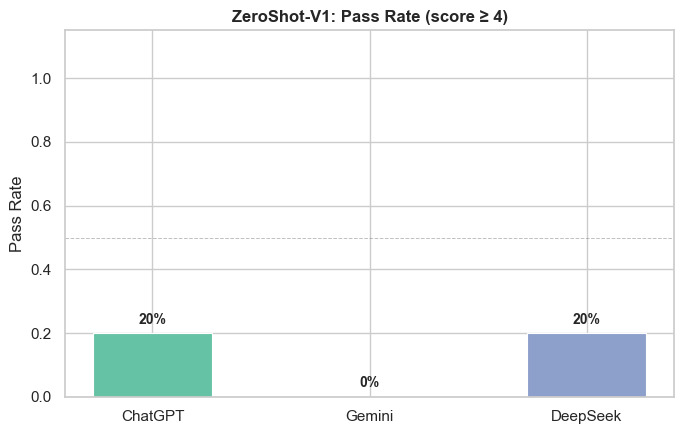


  FewShot-5-Random-V1
   Model  N  Pass Rate  Pass  Fail
 ChatGPT 30      0.633    19    11
  Gemini 30      0.533    16    14
DeepSeek 30      0.500    15    15

  Saved: figures/fewshot_5_random_v1_results.png


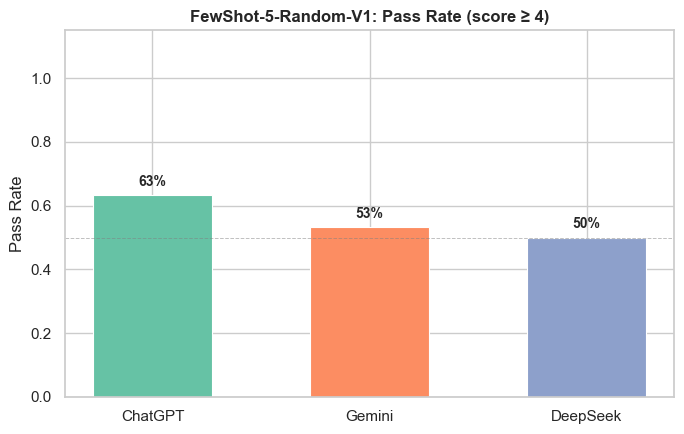


  FewShot-5-Random-V2
   Model  N  Pass Rate  Pass  Fail
 ChatGPT 30      0.600    18    12
  Gemini 30      0.900    27     3
DeepSeek 30      0.433    13    17



  Saved: figures/fewshot_5_random_v2_results.png


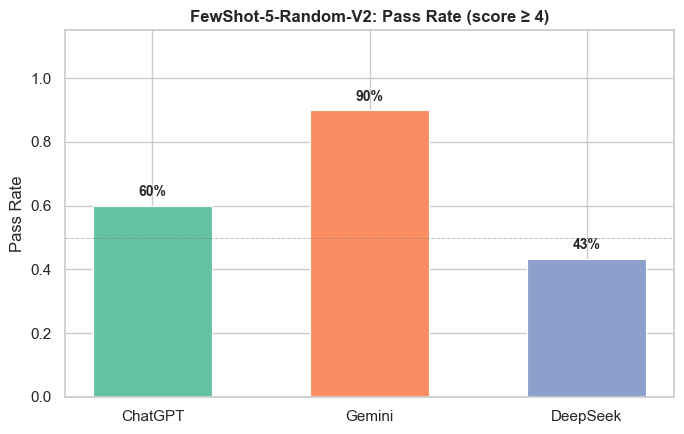

  (excluded 1 row(s) for SID(s) [15])

  FewShot-10-Random-V1
   Model  N  Pass Rate  Pass  Fail
 ChatGPT 29      0.759    22     7
  Gemini 29      0.724    21     8
DeepSeek 29      0.379    11    18



  Saved: figures/fewshot_10_random_v1_results.png


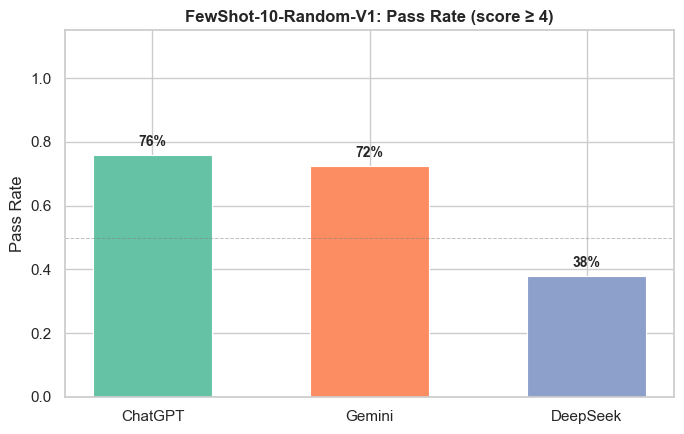


  FewShot-10-Random-V2
   Model  N  Pass Rate  Pass  Fail
 ChatGPT 29      0.828    24     5
  Gemini 29      0.793    23     6
DeepSeek 29      0.483    14    15



  Saved: figures/fewshot_10_random_v2_results.png


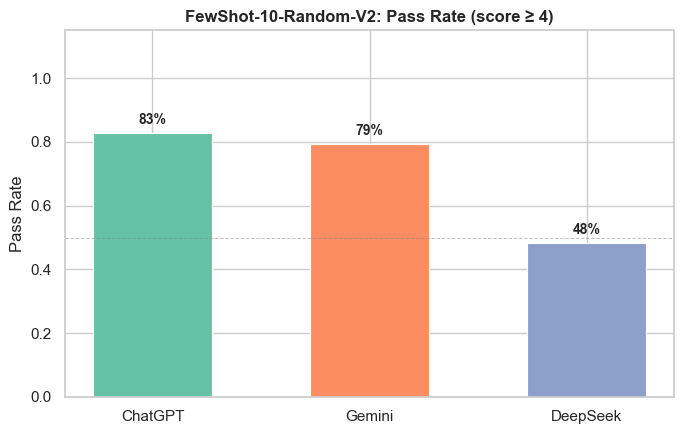


  Manual-Prompting
   Model  N  Pass Rate  Pass  Fail
 ChatGPT 30        0.3     9    21
  Gemini 30        0.8    24     6
DeepSeek 30        0.6    18    12



  Saved: figures/manual_exp_results.png


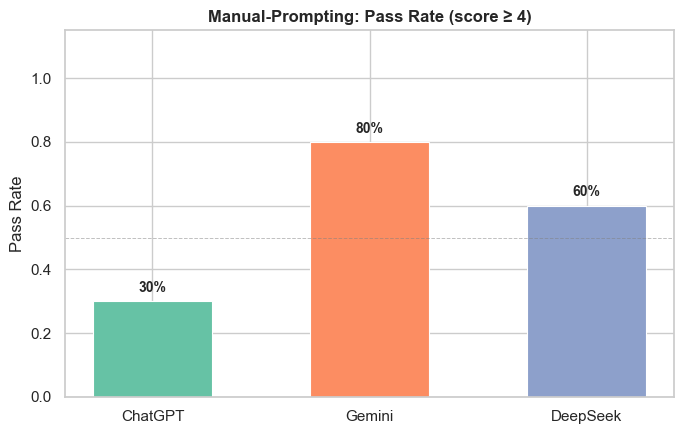


Done — all experiments analyzed.


In [3]:
all_results = []
for name, cfg in EXPERIMENTS.items():
    r = analyze_experiment(cfg["sheet"], name, cfg["header"])
    all_results.append(r)

summary = pd.concat(all_results, ignore_index=True)
print("\nDone — all experiments analyzed.")

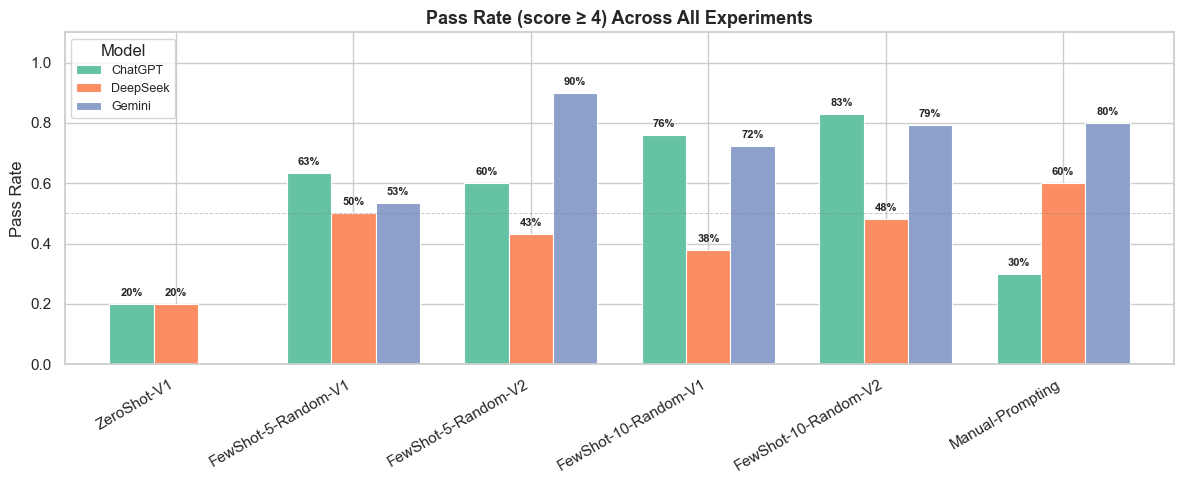

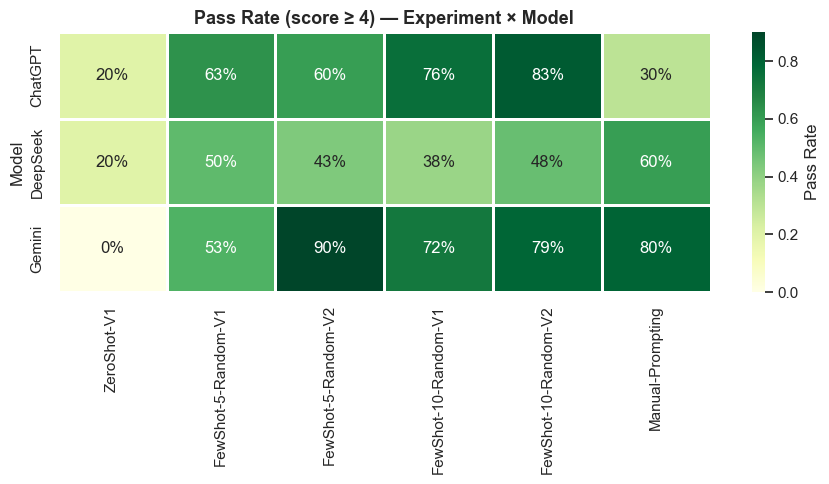

In [4]:
# ── Grouped bar chart: pass rate across all experiments ──
fig, ax = plt.subplots(figsize=(12, 5))
pivot = summary.pivot_table(index="Experiment", columns="Model",
                             values="Pass Rate", aggfunc="first")
order = list(EXPERIMENTS.keys())
pivot = pivot.reindex(order)
pivot.plot(kind="bar", ax=ax, color=["#66c2a5", "#fc8d62", "#8da0cb"],
           edgecolor="white", linewidth=0.8, width=0.75)
ax.set_title("Pass Rate (score ≥ 4) Across All Experiments", fontsize=13, fontweight="bold")
ax.set_ylabel("Pass Rate")
ax.set_ylim(0, 1.1)
ax.set_xlabel("")
ax.legend(title="Model", fontsize=9)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.4)

# Annotate bars
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                    f"{h:.0%}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/all_experiments_pass_rate.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Heatmap: pass rates ──
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot.T, annot=True, fmt=".0%", cmap="YlGn", linewidths=1,
            cbar_kws={"label": "Pass Rate"}, ax=ax)
ax.set_title("Pass Rate (score ≥ 4) — Experiment × Model", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/all_experiments_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

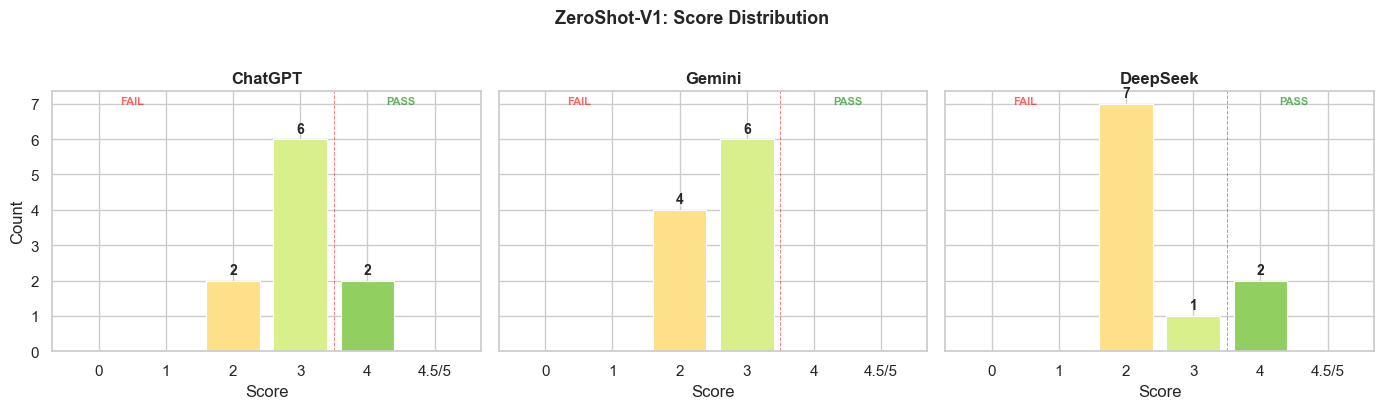

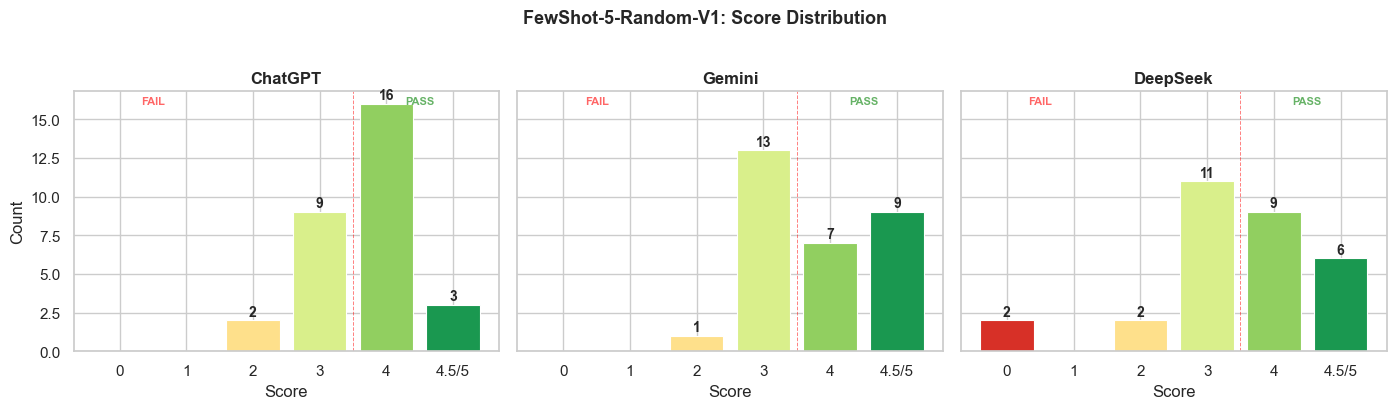

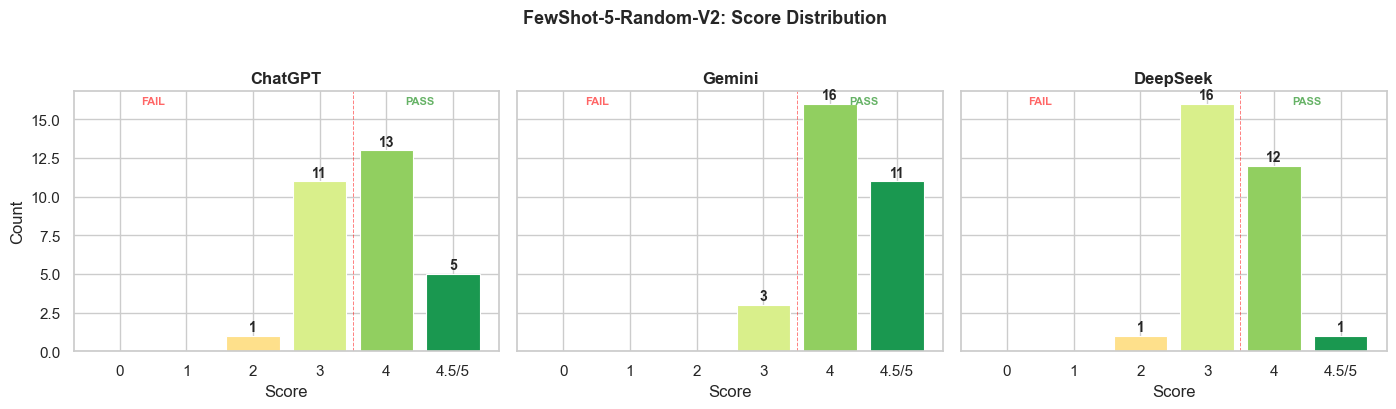

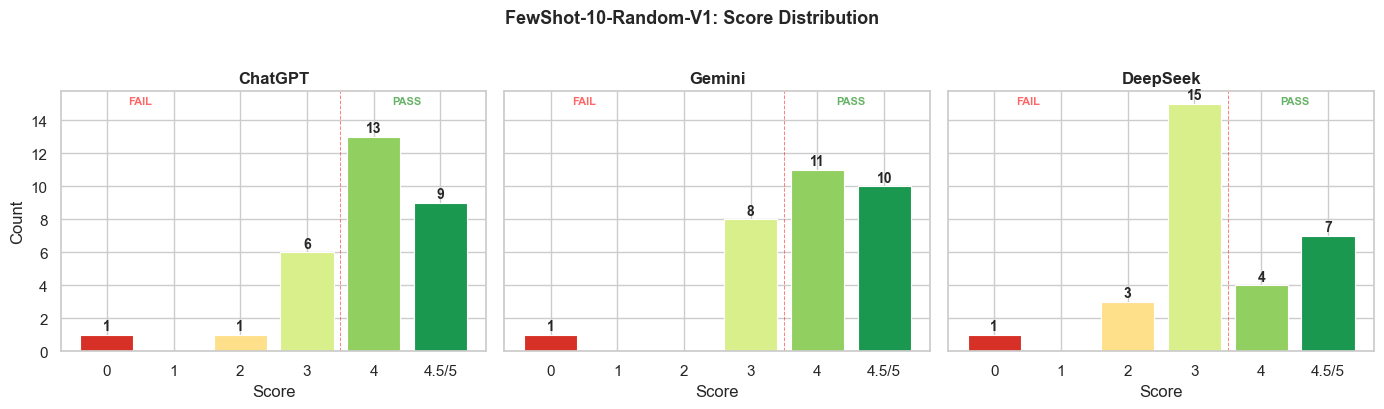

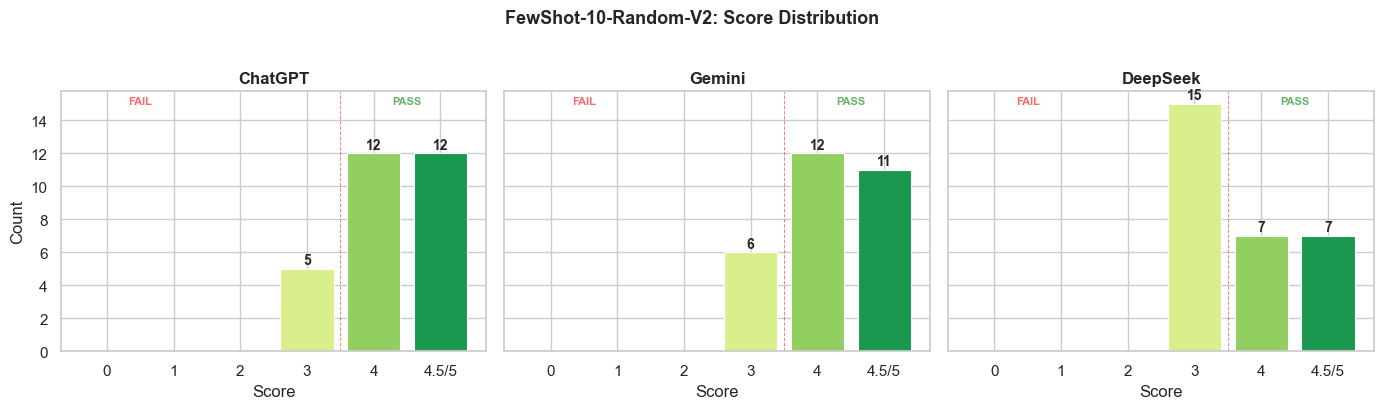

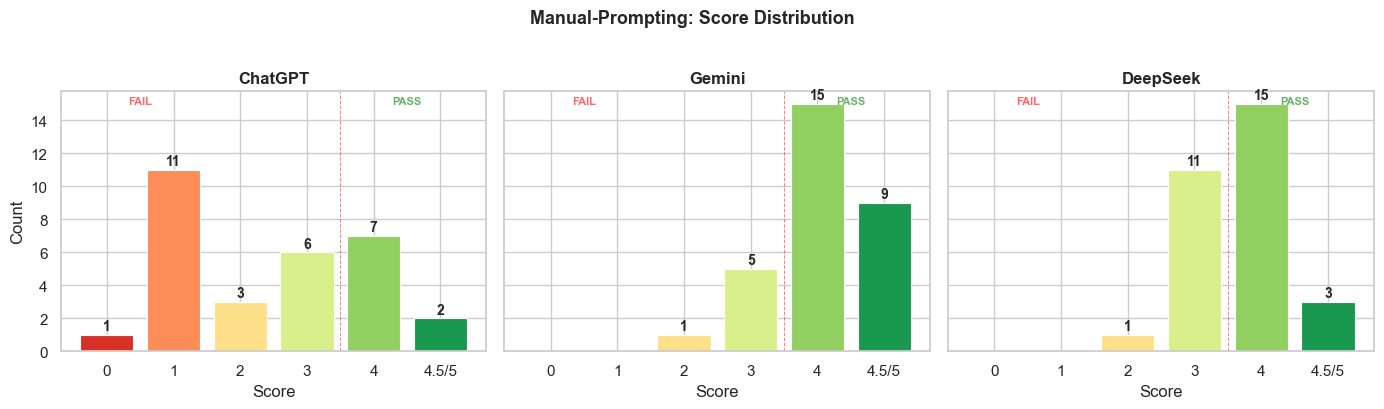

In [5]:
def score_distribution(sheet_name, title, header=0):
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, header=header)
    df.columns = [str(c) for c in df.columns]

    # Identify score columns
    score_cols = {}
    for mdl, sheet_mdl in SHEET_MODEL_MAP.items():
        candidates = [c for c in df.columns if sheet_mdl in str(c) and "Unnamed" not in str(c)]
        for c in candidates:
            if "emarks" not in str(c) and "ass?" not in str(c) and "valuated" not in str(c):
                score_cols[mdl] = c
                break

    bins = [0, 1, 2, 3, 4, 4.5, 5]
    labels = ["0", "1", "2", "3", "4", "4.5/5"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, mdl in zip(axes, MODEL_COLS):
        col = score_cols.get(mdl)
        if col is None or col not in df.columns:
            ax.set_title(f"{mdl}: no data")
            continue
        scores = df[col].dropna()
        # Bucket: put 4.5 and 5 together, 4 alone
        bucket = scores.copy()
        bucket = bucket.apply(lambda x: "4.5/5" if x >= 4.5 else (str(int(x)) if x == int(x) else str(x)))
        # Count by bucket
        order = ["0", "1", "2", "3", "4", "4.5/5"]
        counts = bucket.value_counts().reindex(order, fill_value=0)
        colors_dist = ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#91cf60", "#1a9850"]
        bars = ax.bar(order, counts.values, color=colors_dist, edgecolor="white", linewidth=0.8)
        for bar, val in zip(bars, counts.values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                        str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.set_title(f"{mdl}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Score")
        ax.axvline(x=3.5, color="red", linestyle="--", linewidth=0.7, alpha=0.5,
                   label="Pass/fail boundary")
        if mdl == "ChatGPT":
            ax.set_ylabel("Count")
        # Mark pass/fail region
        ax.text(0.5, 0.95, "FAIL", transform=ax.get_xaxis_transform(),
                ha="center", fontsize=8, color="red", alpha=0.6, fontweight="bold")
        ax.text(4.5, 0.95, "PASS", transform=ax.get_xaxis_transform(),
                ha="center", fontsize=8, color="green", alpha=0.6, fontweight="bold")

    fig.suptitle(f"{title}: Score Distribution", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    safe_name = sheet_name.replace(" ", "_")
    plt.savefig(f"{FIG_DIR}/{safe_name}_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

# Run for all experiments
for name, cfg in EXPERIMENTS.items():
    score_distribution(cfg["sheet"], name, cfg["header"])

In [6]:
# Print a clean summary table for the thesis
def print_summary_table(all_results_df):
    pivot = all_results_df.pivot_table(
        index="Experiment", columns="Model",
        values=["N", "Pass Rate", "Pass", "Fail"],
        aggfunc="first"
    )
    # Reorder columns for readability
    pivot = pivot.reorder_levels([1, 0], axis=1).sort_index(axis=1)
    print("Semantic Evaluation Summary (score ≥ 4 = pass)\n")
    print(pivot.to_string())

print_summary_table(summary)

Semantic Evaluation Summary (score ≥ 4 = pass)

Model                ChatGPT                    DeepSeek                    Gemini                   
                        Fail   N Pass Pass Rate     Fail   N Pass Pass Rate   Fail   N Pass Pass Rate
Experiment                                                                                           
FewShot-10-Random-V1       7  29   22     0.759       18  29   11     0.379      8  29   21     0.724
FewShot-10-Random-V2       5  29   24     0.828       15  29   14     0.483      6  29   23     0.793
FewShot-5-Random-V1       11  30   19     0.633       15  30   15     0.500     14  30   16     0.533
FewShot-5-Random-V2       12  30   18     0.600       17  30   13     0.433      3  30   27     0.900
Manual-Prompting          21  30    9     0.300       12  30   18     0.600      6  30   24     0.800
ZeroShot-V1                8  10    2     0.200        8  10    2     0.200     10  10    0     0.000
